----------- Epoch- 1 Starts -----------
Input:
[[0.66666667 1.        ]
 [0.33333333 0.55555556]
 [1.         0.66666667]]
Actual Output:
[[0.92]
 [0.86]
 [0.89]]
Predicted Output:
[[0.8915966 ]
 [0.87949795]
 [0.89353972]]
----------- Epoch- 1 Ends -----------

----------- Epoch- 2 Starts -----------
Input:
[[0.66666667 1.        ]
 [0.33333333 0.55555556]
 [1.         0.66666667]]
Actual Output:
[[0.92]
 [0.86]
 [0.89]]
Predicted Output:
[[0.89160973]
 [0.87951114]
 [0.8935527 ]]
----------- Epoch- 2 Ends -----------

----------- Epoch- 3 Starts -----------
Input:
[[0.66666667 1.        ]
 [0.33333333 0.55555556]
 [1.         0.66666667]]
Actual Output:
[[0.92]
 [0.86]
 [0.89]]
Predicted Output:
[[0.89162274]
 [0.87952422]
 [0.89356557]]
----------- Epoch- 3 Ends -----------

----------- Epoch- 4 Starts -----------
Input:
[[0.66666667 1.        ]
 [0.33333333 0.55555556]
 [1.         0.66666667]]
Actual Output:
[[0.92]
 [0.86]
 [0.89]]
Predicted Output:
[[0.89163564]
 [0.87953718]
 [

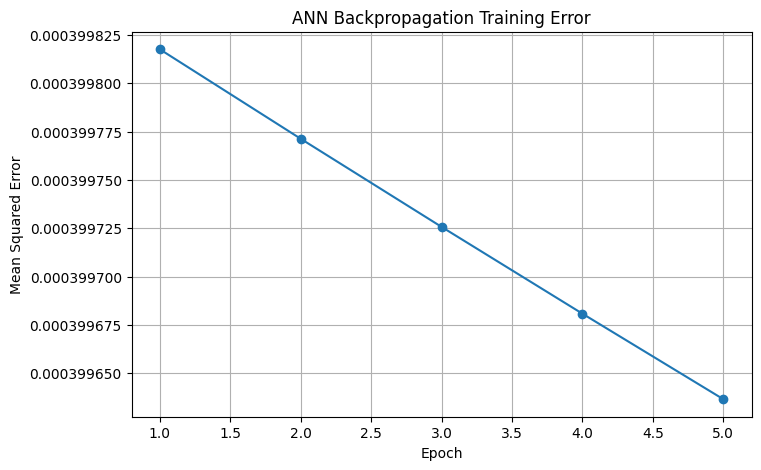

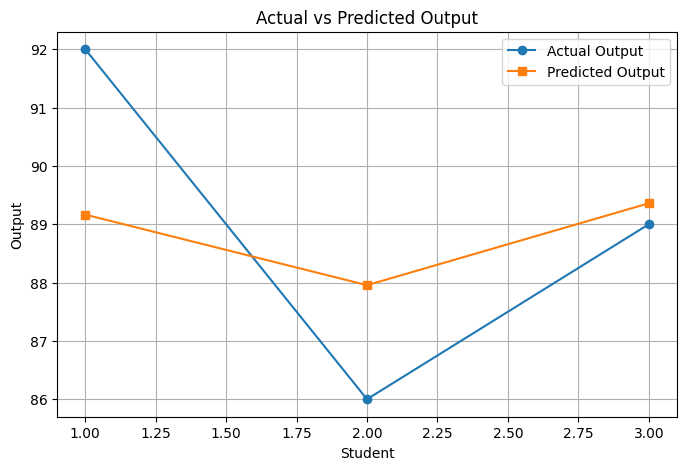

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Input data
X = np.array(
    ([2, 9],
     [1, 5],
     [3, 6]),
    dtype=float
)

# Output data
y = np.array(
    ([92],
     [86],
     [89]),
    dtype=float
)

# Normalize input data
X = X / np.amax(X, axis=0)

# Normalize output data
y = y / 100

# Sigmoid Function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivative of Sigmoid Function
def derivatives_sigmoid(x):
    return x * (1 - x)

# Variable initialization
epoch = 5
lr = 0.1

inputlayer_neurons = 2
hiddenlayer_neurons = 3
output_neurons = 1

# Weight and bias initialization
np.random.seed(42)

wh = np.random.uniform(
    size=(inputlayer_neurons, hiddenlayer_neurons)
)

bh = np.random.uniform(
    size=(1, hiddenlayer_neurons)
)

wout = np.random.uniform(
    size=(hiddenlayer_neurons, output_neurons)
)

bout = np.random.uniform(
    size=(1, output_neurons)
)

# Store error
error_history = []

# Training
for i in range(epoch):

    # Forward Propagation
    hinp1 = np.dot(X, wh)
    hinp = hinp1 + bh

    hlayer_act = sigmoid(hinp)

    outinp1 = np.dot(hlayer_act, wout)
    outinp = outinp1 + bout

    output = sigmoid(outinp)

    # Backpropagation
    EO = y - output

    outgrad = derivatives_sigmoid(output)

    d_output = EO * outgrad

    EH = d_output.dot(wout.T)

    hiddengrad = derivatives_sigmoid(hlayer_act)

    d_hiddenlayer = EH * hiddengrad

    # Updating Weights
    wout += hlayer_act.T.dot(d_output) * lr

    wh += X.T.dot(d_hiddenlayer) * lr

    # Updating Bias
    bout += np.sum(d_output, axis=0, keepdims=True) * lr

    bh += np.sum(d_hiddenlayer, axis=0, keepdims=True) * lr

    # Calculate Error
    error = np.mean(np.square(y - output))
    error_history.append(error)

    # Display Output
    print("----------- Epoch-", i + 1, "Starts -----------")

    print("Input:")
    print(X)

    print("Actual Output:")
    print(y)

    print("Predicted Output:")
    print(output)

    print("----------- Epoch-", i + 1, "Ends -----------")
    print()

# Final output
print("====================================")
print("FINAL OUTPUT")
print("====================================")

print("Actual Output:")
print(y * 100)

print("\nPredicted Output:")
print(output * 100)

# Error Graph
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, epoch + 1),
    error_history,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("ANN Backpropagation Training Error")
plt.grid(True)
plt.show()

# Actual vs Predicted Graph
plt.figure(figsize=(8, 5))

students = np.arange(1, len(y) + 1)

plt.plot(
    students,
    y.flatten() * 100,
    marker='o',
    label="Actual Output"
)

plt.plot(
    students,
    output.flatten() * 100,
    marker='s',
    label="Predicted Output"
)

plt.xlabel("Student")
plt.ylabel("Output")
plt.title("Actual vs Predicted Output")
plt.legend()
plt.grid(True)
plt.show()